In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import glob, os, sys
import scanpy as sc
import pandas as pd
import scvi 

print("Last run with scvi-tools version:", scvi.__version__)

Last run with scvi-tools version: 1.3.3


In [2]:
# function for mygene 
import mygene, re, warnings
mg = mygene.MyGeneInfo()

def fetch_chr_mygene(symbols, chunk=1000):
    allowed = {str(i) for i in range(1,20)} | {"X","Y","MT"}
    out = {}
    for i in range(0, len(symbols), chunk):
        chunk_syms = symbols[i:i+chunk]        
        hits = mg.querymany(
            chunk_syms,
            scopes="symbol",
            fields="genomic_pos,genomic_pos_hg19,map_location,symbol",
            species="mouse",
            as_dataframe=False,
            returnall=False,
            verbose=False,
        for h in hits:
            q = h.get("query")
            c = None
            # prefer genomic_pos.chr
            gp = h.get("genomic_pos")
            if isinstance(gp, list) and gp:
                gp = gp[0]
            if isinstance(gp, dict):
                c = gp.get("chr")
            if c is None:
                ml = h.get("map_location")
                if isinstance(ml, str):
                    c = re.split(r"[ ;,]", ml.strip())[0]
            if isinstance(c, str):
                c = c.replace("chr","").upper()
            if c in allowed and q not in out:
                out[q] = c
    return out

# load the output from R scripts

In [3]:
adata_sc_orig = sc.read_h5ad("../data/snRNAseq_LCNE/snRNAseq_LCNE.h5ad")
adata_sc_orig.obs['actualsex'] = adata_sc_orig.obs['sex'].str[0]  # take only first character 'M' or 'F'

# get gene symbols
symbols = adata_sc_orig.var_names.astype(str).tolist()


In [4]:
gene_to_chr = fetch_chr_mygene(symbols)  # get the chromosomal info!
adata_sc_orig.var["chromosome"] = adata_sc_orig.var_names.map(gene_to_chr).astype("category")


# lets just save this so that we dont need to run query all the time 
adata_sc_orig.write("../scratch/snRNAseq_LCNE_with_chrom.h5ad")


Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequen

# filter out X/Y chromosomes <- but you should not be worry since this step is also ran on 02 notebook (after loading the saved file in scratch) 
- optional: also remove `MT` genes (mitochondria)

In [13]:
remove_MT_gene = True # default should be true 

In [23]:

mask_xy = adata_sc_orig.var["chromosome"].isin(["X","Y"])
adata_noXY = adata_sc_orig[:, ~mask_xy.fillna(False)].copy()
print(f'found {mask_xy.sum()} XY genes, removing')

if remove_MT_gene:
    mask_mt = adata_noXY.var["chromosome"].isin(["MT"])
    print(f'found {sum(mask_mt)} mitochondria genes, removing')
    adata_noXY_nomt = adata_noXY[:, ~mask_mt.fillna(False)].copy()
    adata_noXY = adata_noXY_nomt.copy()
    print(f"\nMapped {adata_sc_orig.var['chromosome'].notna().sum()} / {adata_sc_orig.n_vars} genes; "
      f"removed {int(mask_xy.sum()+mask_mt.sum())} on X/Y/MT")
else:
    print(f"\nMapped {adata_sc_orig.var['chromosome'].notna().sum()} / {adata_sc_orig.n_vars} genes; "
      f"removed {int(mask_xy.sum())} on X/Y")

found 912 XY genes, removing
found 13 mitochondria genes, removing

Mapped 27389 / 29617 genes; removed 925 on X/Y/MT


# some sanity check 

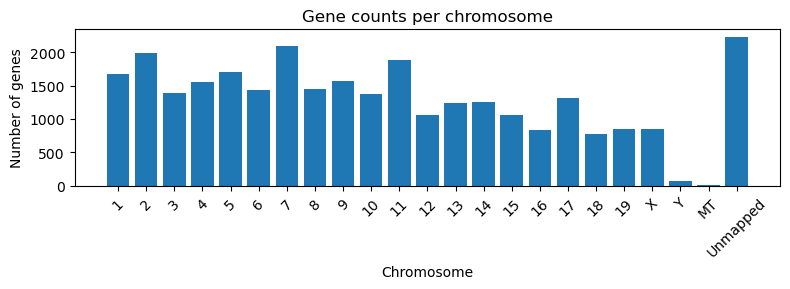

In [35]:

chrom = adata_sc_orig.var['chromosome'].cat.add_categories(['Unmapped'])
chrom = chrom.fillna('Unmapped')
order = [str(i) for i in range(1, 20)] + ['X', 'Y', 'MT', 'Unmapped']
chrom = pd.Categorical(chrom, categories=order, ordered=True)
adata_sc_orig.var['chromosome'] = chrom
counts = chrom.value_counts().reindex(order)

plt.figure(figsize=(8, 3))
plt.bar(counts.index, counts.values)
plt.xlabel("Chromosome")
plt.ylabel("Number of genes")
plt.xticks(rotation=45)
plt.title("Gene counts per chromosome")
plt.tight_layout()
plt.show()


## check: How many symbols failed to map?

In [39]:

n_unmapped = (adata_sc_orig.var['chromosome']=='Unmapped').sum()
n_unmapped, n_unmapped / adata_sc_orig.n_vars


(np.int64(2228), np.float64(0.07522706553668501))

### Inspect a few unmapped symbols (often Gm* etc.)

In [42]:

adata_sc_orig.var_names[adata_sc_orig.var['chromosome']=='Unmapped'][:20].tolist()

['Gm28653',
 '4933415F23Rik',
 '4931408C20Rik',
 'Gm597',
 'Ptp4a1 ENSMUSG00000117310',
 '4931428L18Rik',
 'Gm5415',
 '2010300C02Rik',
 'Gm8251',
 'Gm553',
 'Fam126b',
 '1700122D07Rik',
 'Gpr1',
 'Gm39653',
 'March4',
 '1700027A15Rik',
 '2310015K22Rik',
 'Gm29125',
 'Gm45261',
 'Gm9747']

## (optional) are there sexually DE genes after removing the XY chromosomes? 

In [43]:
adata_noXY.shape

(4868, 28692)

In [44]:
adata_noXY

AnnData object with n_obs × n_vars = 4868 × 28692
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample_id', 'bc', 'ar_id', 'umi.counts', 'barcodes', 'gene.counts.0', 'gene.counts.1', 'gene.counts.4', 'gene.counts.8', 'gene.counts.16', 'gene.counts.32', 'gene.counts.64', 'exclude', 'exp_component_name', 'exp_component_vendor_name', 'batch', 'batch_vendor_name', 'tube', 'tube_internal_name', 'tube_contents_nm', 'tube_contents_nm_from_vendor', 'tube_avg_size_bp', 'tube_input_fmol', 'r1_index', 'r2_index', 'index_sequence_pair', 'organism', 'facs_container', 'sample_name', 'patched_cell_container', 'cell_name', 'cell_id', 'studies', 'hemisphere_name', 'sample_quantity_count', 'sample_quantity_pg', 'donor_name', 'external_donor_name', 'age', 'species', 'sex', 'control', 'X', 'full_genotype', 'facs_population_plan', 'cre_line', 'reporter', 'cell_prep_sample_name', 'injection_roi', 'injection_method', 'injection_materials', 'roi', 'patchseq_roi', 'medical_conditions', 'slice_min_pos',

It seems you use rank_genes_groups on the raw count data. Please logarithmize your data before calling rank_genes_groups.
/opt/conda/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:479: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/opt/conda/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:480: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
/opt/conda/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:479: RuntimeWarning: invalid value encountered in divide
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/opt/conda/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:479: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/opt/conda/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:480: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9

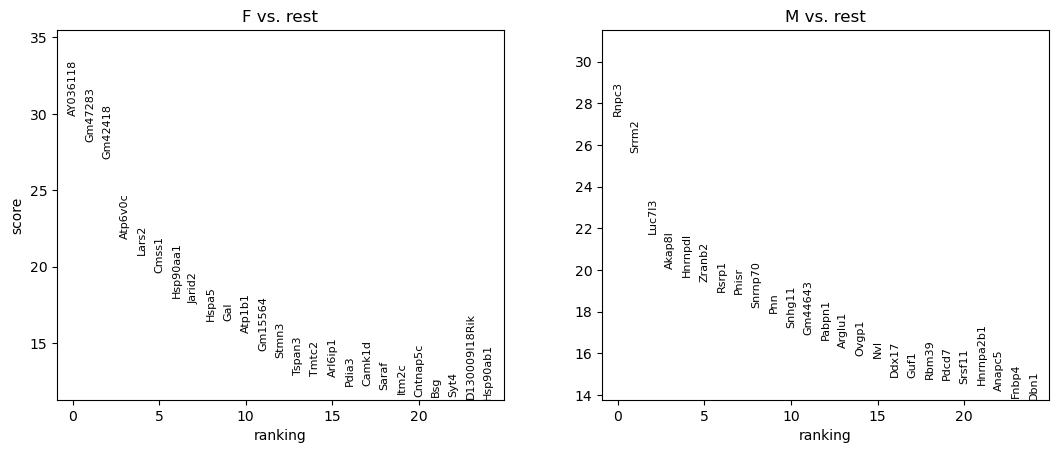

3799 sex-differential genes removed, 24893 genes remain.


In [45]:
## lognormalize otherwise get yelled at`
adata_noXY.layers["CPM"] = adata_noXY.X.copy()
sc.pp.normalize_total(adata_noXY, target_sum=1e6, layer="CPM")
adata_noXY.layers["log(CPM)"] = adata_noXY.layers["CPM"].copy()
sc.pp.log1p(adata_noXY, layer="log(CPM)")


sc.tl.rank_genes_groups(
    adata_noXY,
    groupby='actualsex',
    method='wilcoxon',  # or 't-test' or 'logreg'
)


sc.pl.rank_genes_groups(adata_noXY, n_genes=25, sharey=False)
result = adata_noXY.uns['rank_genes_groups']
pd.DataFrame({
    group: result['names'][group]
    for group in result['names'].dtype.names
}).head()


alpha = 0.05
min_lfc = 0.25  # ~log2 FC if using base-2; Scanpy uses natural log FC
df = sc.get.rank_genes_groups_df(adata_noXY, group=None)  # columns: names, scores, logfoldchanges, pvals_adj, group
sig = df[(df['pvals_adj'] < alpha) & (df['logfoldchanges'].abs() >= min_lfc)]
sex_genes = sig['names'].unique()
adata_nosex = adata_noXY[:, ~adata_noXY.var_names.isin(sex_genes)].copy()
print(len(sex_genes), "sex-differential genes removed,", adata_nosex.n_vars, "genes remain.")

# how many of these are HVGs? 

In [46]:
adata_nosex.shape, adata_noXY.shape

((4868, 24893), (4868, 28692))

In [47]:

sc.pp.highly_variable_genes(adata_noXY, n_top_genes=1500, flavor="seurat_v3",subset=False)
hvg_genes = adata_noXY.var_names[adata_noXY.var['highly_variable']].tolist()

In [48]:
len(list(sex_genes)), len(list(hvg_genes)), # 3923, 1500

(3799, 1500)

In [49]:
len(set(sex_genes).intersection(set(hvg_genes))) # thats not even so many overlaps. 

248

In [50]:
mask_xy = adata_sc_orig.var["chromosome"].isin(["X",'Y'])
mask_mt = adata_sc_orig.var["chromosome"].isin(["MT"])
mask_nan_chrom = adata_sc_orig.var["chromosome"].isna()
mask_xy_or_nan_or_mt = mask_xy | mask_nan_chrom | mask_mt

print(adata_sc_orig.shape[1],'before removing genes')
adata_sc_orig = adata_sc_orig[:, ~mask_xy_or_nan_or_mt.fillna(False)].copy()
print(adata_sc_orig.shape[1],'after removing genes')

29617 before removing genes
28692 after removing genes
